# Where the Water Flows -- Glacier de Bonne Pierre

In [6]:
using Pkg; Pkg.activate("/scratch-1/cogier/hydraulic_barriers/")
Pkg.resolve()
using Rasters
using Shapefile
using WhereTheWaterFlowsSubglacially, WhereTheWaterFlows
const WWFS = WhereTheWaterFlowsSubglacially
const WWF = WhereTheWaterFlows
using ArchGDAL
#using MAT
using Plots
#using GlacioTools
#Pkg.status()



  Activating project at `/scratch-1/cogier/hydraulic_barriers`
  No Changes to `/scratch-1/cogier/hydraulic_barriers/Project.toml`
  No Changes to `/scratch-1/cogier/hydraulic_barriers/Manifest.toml`


In [8]:
datadir = "/scratch-3/cogier/data/DEM"
#include("helper_functions.jl")

"/scratch-3/cogier/data/DEM"

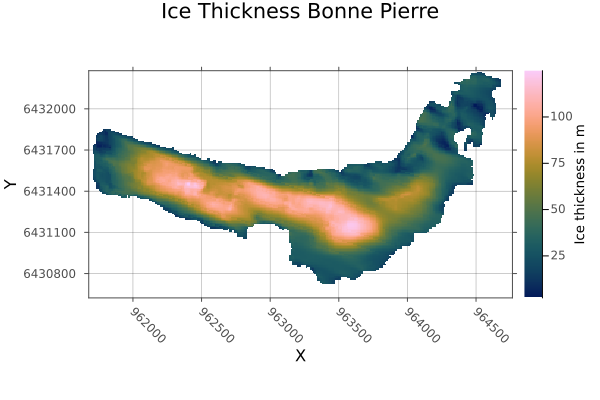

In [17]:
# Bonne Pierre
ice_thickness = Raster(joinpath(datadir,"IceThickness_BP_2024.tif"));
bed = Raster(joinpath(datadir,"Bedrock_BP_2024.tif"));
Plots.heatmap(ice_thickness,title="Ice Thickness Bonne Pierre", 
colorbar_title="Ice thickness in m")

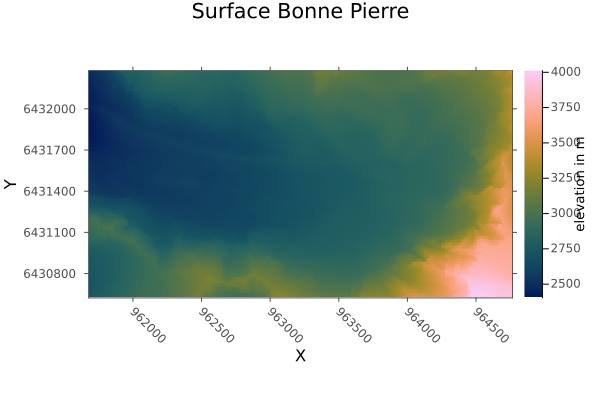

In [ ]:

# Surface DEM = IceThickness + Bedrock
surface_nov_2024 = bed + ice_thickness;

# Clip the  2021 surface raster to the extent of the bedrock raster
all_surf_2021 = Raster(joinpath(datadir,"Berarde_Res1.0_CompElevmean_merged.tif"));
surface_2021 = crop(surf_2021; to=bed)
surface_2021_resamp = resample(surface_2021; to=bed)
# plot
Plots.heatmap(surface_2021_resamp,title="Surface Bonne Pierre 2021", 
colorbar_title="elevation in m")

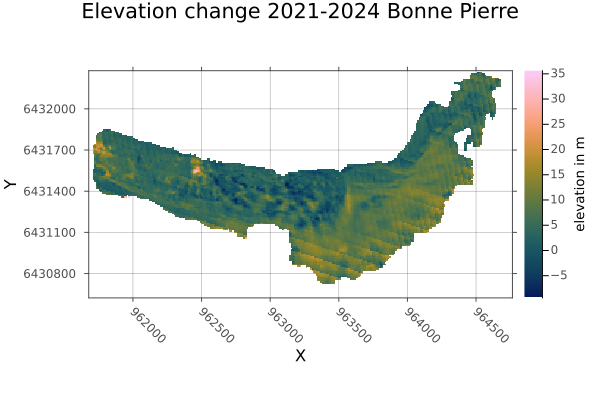

In [38]:
# difference surface 2021 and 2024

Plots.heatmap(surface_2021_resamp - surface_nov_2024,title="Elevation change 2021-2024 Bonne Pierre", 
colorbar_title="elevation in m")

In [ ]:
bed_trient_1928_cr_resamp = resample(bed_trient_1928_cr, to=surf_trient_1928);

In [ ]:
## run WWFS and save data

# with gamma = -0.31 (Rothlisberger constant = stream deflection)
(area_r, slen_r, dir, nout_r, nin_r, pits_r, c_r, bnds_r),
         (sc_locs_r, kappas_r, diro_r, phi_r),
         (lakes_r, lakes_free_surf_r),
         sinkout_r = WWFS.waterflows_subglacial(surf_trient_1928[:,:,1], bed_trient_1928_cr_resamp[:, :, 1], gamma=[0,WWFS.GAMMA][2], bnd_as_pits=true, drain_pits=true);

write(joinpath(datadir,"WWFS_output","area_r_trient1928.tif"),area_r);
write(joinpath(datadir,"WWFS_output","lakes_r_trient1928.tif"),lakes_r);
write(joinpath(datadir,"WWFS_output","phi_r_trient1928.tif"),phi_r); # shreve potential

         

In [ ]:
#Argentières
"""
filebed = matopen(joinpath(datadir,"alps/DEMbed_IncludingSeracs_20m_LambertIIEtendu.mat"));
filesurf = matopen(joinpath(datadir,"alps/DEMsurf_2018_NotIncludingSeracs_2m_LambertIIEtendu.mat")); # bed and surf are not the same size !
bedx = read(filebed, "X")[1,:] #longitude, dx=20m
bedy = read(filebed, "Y")[:,1] #latitude, dx=20m
bedz = read(filebed, "Zbed_christian");
surfx = read(filesurf, "X")[1,:] #longitude, dx=20m
surf = read(filesurf, "Y")[:,1] #latitude, dx=20m
surfz = read(filesurf, "Zsurf");
"""



In [ ]:
# Findelen surface in 1931
surf_findelen_1931 = Raster(joinpath(datadir,"alps/findelen_1931_25m_lv95.tif"));
Plots.heatmap(surf_findelen_1931)

In [ ]:
# bedrock of findelen 2016
#geom_select("Findelen","B56-03", datadir, do_save=true); 
findelen_BedElev_2016 = Raster(joinpath(datadir,"alps/Findelen_BedElev_cr.tif"));

In [ ]:
# Merge bed rock of 2016 and surface elevation 2019 -> that makes glacier free topography ONLY for findelen though
all_bed_findelen = mosaic(first, findelen_BedElev_2016, all_surf_2019);  # in case of overlap, we take the values of all_bed first

In [ ]:
Plots.heatmap(all_bed_findelen)

In [ ]:
#crop surface elevation to bed data to match dimension (before substracting)
bed_findelen_1931_cr = crop(all_bed_findelen; to=surf_findelen_1931);
bed_findelen_1931_cr[bed_findelen_1931_cr .< 0] .= NaN; #missing values in all_surf is -3.4028235e38
Plots.heatmap(bed_findelen_1931_cr)

In [ ]:
Plots.heatmap(surf_findelen_1931)

In [ ]:
bed_findelen_1931_cr_resamp = resample(bed_findelen_1931_cr, to=surf_findelen_1931)

In [ ]:
size(surf_findelen_1931) == size(bed_findelen_1931_cr_resamp)

In [ ]:
write(joinpath(datadir,"alps","Findelen_bed_1931_25m.tif"),bed_findelen_1931_cr_resamp);

In [ ]:
# with gamma = -0.31 (Rothlisberger constant = stream deflection)
(area_r, slen_r, dir, nout_r, nin_r, pits_r, c_r, bnds_r),
         (sc_locs_r, kappas_r, diro_r, phi_r),
         (lakes_r, lakes_free_surf_r),
         sinkout_r = WWFS.waterflows_subglacial(surf_findelen_1931[:,:,1], bed_findelen_1931_cr_resamp[:, :, 1], gamma=[0,WWFS.GAMMA][2], bnd_as_pits=true, drain_pits=true);

In [ ]:
write(joinpath(datadir,"WWFS_output","area_r_findelen1931.tif"),area_r);
write(joinpath(datadir,"WWFS_output","lakes_r_findelen1931.tif"),lakes_r);
write(joinpath(datadir,"WWFS_output","phi_r_findelen1931.tif"),phi_r); # shreve potential
